In [3]:
import sys, os
import random
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
sys.path.append(os.path.abspath(".."))

In [4]:
np.random.seed(1337)
random.seed(1337)

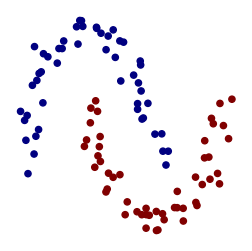

In [5]:
# generate some random data
from sklearn.datasets import make_moons, make_blobs
X, y = make_moons(n_samples=100, noise=0.1)

y = y*2 - 1
plt.figure(figsize=(3,3))
plt.scatter(X[:,0], X[:,1], c=y, s=20, cmap='jet')
plt.axis('off');

In [6]:
# loss function
from micrograd.engine import Value
from micrograd.nn import Neuron, Layer, MLP

# two layer neural network
model = MLP(2, [16, 16, 1]) 

def loss(batch_size=None):
    
    # inline dataloader
    if batch_size is None:
        Xb, yb = X, y
    else:
        
        # grab a random sample of shuffled indices from X of size batch_size
        # assuming X has size Nxd, then X[0] is the number of samples in X = N
        ri = np.random.permutation(X.shape[0])[:batch_size]
        Xb, yb = X[ri], y[ri]
        
    # for each sample in the batched data, convert the values into Value()
    # inputs = array of Values()
    inputs = [list(map(Value, xrow)) for xrow in Xb]
    
    # for each value in inputs, evaluate the model on it
    scores = list(map(model, inputs))
    
    ''' didn't really try to implement this part... revisit later '''
    # implement the svm loss for this problem
    losses = [(1 + -yi*scorei).relu() for yi, scorei in zip(yb, scores)]
    data_loss = sum(losses) * (1.0 / len(losses))
    
    # L2 regularization
    alpha = 1e-4
    reg_loss = alpha * sum((p*p for p in model.parameters()))
    total_loss = data_loss + reg_loss
    
    # also get accuracy
    accuracy = [(yi > 0) == (scorei.data > 0) for yi, scorei in zip(yb, scores)]
    return total_loss, sum(accuracy) / len(accuracy)
    

In [7]:
# optimization step / learning step
for epoch in range(100):
    
    # forward pass
    total_loss, acc = loss(32)
    
    # backward
    model.zero_grad()
    total_loss.backward()
    
    # update (sgd)
    learning_rate = 1.0 - 0.9*epoch/100
    for p in model.parameters():
        p.data -= learning_rate * p.grad
        
    if epoch % 10 == 0:
        print(f"step: {epoch} loss {total_loss.data}, accuracy {acc*100}%")

step: 0 loss 0.8069957122729794, accuracy 56.25%
step: 10 loss 0.31781413617450927, accuracy 87.5%
step: 20 loss 0.2963940147273128, accuracy 87.5%
step: 30 loss 0.06468545920006859, accuracy 100.0%
step: 40 loss 0.2492707234841468, accuracy 87.5%
step: 50 loss 0.2035750760465928, accuracy 90.625%
step: 60 loss 0.11373375339003487, accuracy 96.875%
step: 70 loss 0.011886335595042168, accuracy 100.0%
step: 80 loss 0.013138812112025779, accuracy 100.0%
step: 90 loss 0.010757377351676829, accuracy 100.0%


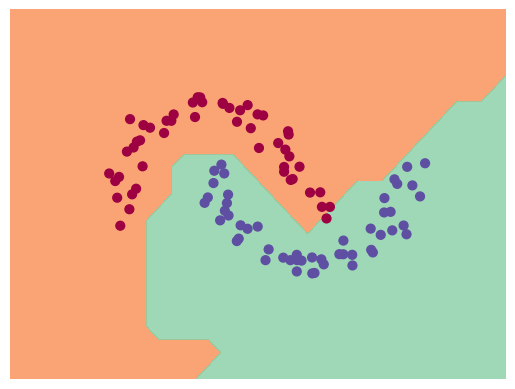

In [8]:
# visualize
h = 0.25
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Xmesh = np.c_[xx.ravel(), yy.ravel()]
inputs = [list(map(Value, xrow)) for xrow in Xmesh]
scores = list(map(model, inputs))
Z = np.array([s.data > 0 for s in scores])
Z = Z.reshape(xx.shape)

fig = plt.figure()
plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.8)
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.Spectral)
plt.xlim(xx.min(), xx.max())
plt.ylim(yy.min(), yy.max())
plt.axis('off');